# 1b. Matrix Multiplication and Centrality

Welcome to the afternoon practical! In this session we connect **linear algebra** to **networks**: the adjacency matrix is not just storage, it is a tool that answers questions about the network when you multiply it by things.

**Learning objectives**

- Represent a network as an adjacency matrix and convert back and forth between formats.
- Understand what `A @ x` and `A @ A` answer about the network.
- Use `A^n` to count walks of length `n`, triangles, and the local clustering coefficient.
- Compute and compare the main centrality measures (degree, closeness, betweenness, eigenvector, PageRank, harmonic, HITS).

**Sections**

0. Setup and helpers
1. Network representations
2. Matrix multiplication = combining neighbour attributes
3. Matrix multiplication and paths
4. Node centrality on the Florentine network
5. Centrality on real networks (Twitter, PPI)
6. Eigenvector and PageRank via the power method
7. Centrality side-by-side comparison


In [1]:
# On Colab, uncomment the following lines to install the required packages
# and to clone the course repository with the data files.
# !pip install python-igraph networkx pandas numpy matplotlib seaborn
# !git clone https://github.com/jgarciab/NetworkScience.git
# import sys
# sys.path.append('/content/NetworkScience/Practicals/day1/')


In [2]:
# Path to the data folder
# On your computer:
path_data = "../../Data/"
# On Colab uncomment:
# path_data = "/content/NetworkScience/Data/"


In [3]:
# Core libraries
import igraph as ig    # Primary network library for this practical
import networkx as nx  # Used only for the florentine_families convenience constructor

# Data and numerics
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Visual style for the whole notebook
custom_params = {
    "axes.spines.right": False, "axes.spines.top": False, "axes.spines.left": False, "axes.spines.bottom": False,
    "lines.linewidth": 2, "grid.color": "lightgray", "legend.frameon": False,
    "xtick.labelcolor": "#484848", "ytick.labelcolor": "#484848",
    "xtick.color": "#484848", "ytick.color": "#484848",
    "text.color": "#484848", "axes.labelcolor": "#484848",
    "axes.titlecolor": "#484848", "figure.figsize": [5, 3],
    "axes.titlelocation": "left",
    "xaxis.labellocation": "left",
    "yaxis.labellocation": "bottom",
}
palette = ["#3d348b", "#e6af2e", "#191716", "#e0e2db"]
sns.set_theme(context='paper', style='white', palette=palette, font_scale=1.3, color_codes=True, rc=custom_params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Reproducibility seeds (igraph layouts use python's random under the hood)
import random
random.seed(1)
np.random.seed(1)


In [4]:
# --- Helper functions for visualisation and conversion (igraph edition) ---
# These are ported from the original NetworkX-based helpers; they use only
# python-igraph + numpy + matplotlib, no scipy.sparse.

def plot_network(g, ax=None, values=None, with_labels=True):
    """Draw an igraph network. Node size and colour are scaled to `values`.

    Adds a colorbar at the bottom.
    """
    n = g.vcount()
    if values is None:
        values = np.array(g.degree()) / max(1, max(g.degree()))
    values = np.asarray(list(values), dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    vmin, vmax = float(values.min()), float(values.max())
    if vmin == vmax:
        vmin, vmax = vmin - 1e-9, vmax + 1e-9
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.coolwarm)
    mapper.set_array([])
    cb = plt.colorbar(mapper, ax=ax, location="bottom", shrink=0.8, pad=0.04, label="value")
    cb.outline.set_visible(False)

    node_colors = [mapper.to_rgba(v) for v in values]
    # Scale node sizes; igraph uses absolute units, so map values to a sensible range
    span = max(values.max() - values.min(), 1e-9)
    sizes = 15 + 30 * (values - values.min()) / span

    labels = None
    if with_labels and "name" in g.vs.attributes():
        labels = g.vs["name"]

    layout = g.layout_fruchterman_reingold()
    ig.plot(
        g,
        target=ax,
        layout=layout,
        vertex_size=sizes,
        vertex_color=node_colors,
        edge_color="darkgray",
        vertex_label=labels,
        vertex_label_size=9,
    )
    ax.set_axis_off()


def plot_table(ax, cellText, rowLabels, colLabels):
    """Render an adjacency matrix as a matplotlib table, highlighting non-zero cells."""
    cellText = pd.DataFrame(cellText)
    colours = (cellText > 0).replace({False: "white", True: "#e6af2e"}).values
    the_table = ax.table(
        cellText=cellText.values,
        rowLabels=rowLabels,
        colLabels=colLabels,
        loc="center",
        colLoc="left",
        cellColours=colours,
    )
    ax.axis(False)
    the_table.scale(0.8, 1.6)


def plot_network_adj(g, values=None):
    """Three-panel display: network, adjacency-as-table, adjacency spy plot."""
    fig, (a0, a1, a2) = plt.subplots(
        1, 3, gridspec_kw={"width_ratios": [1, 1, 0.5]}, figsize=(12, 4)
    )
    plot_network(g, a0, values=values)
    A = np.array(g.get_adjacency().data)
    names = g.vs["name"] if "name" in g.vs.attributes() else list(range(g.vcount()))
    plot_table(a1, A, names, names)
    a2.spy(A)
    sns.despine(bottom=True, left=True)
    a2.grid(True)
    a2.set_xticks(range(len(names)))
    a2.set_xticklabels(names, rotation=90)
    a2.set_yticks(range(len(names)))
    a2.set_yticklabels(names)
    plt.tight_layout()


def adj_to_net(A, names=("Alice", "Bob", "John", "Amy", "Mike", "Rose")):
    """Build a directed igraph from a (dense) adjacency matrix and attach names."""
    A = np.asarray(A)
    g = ig.Graph.Adjacency((A > 0).astype(int).tolist(), mode="directed")
    if names is not None and len(names) == g.vcount():
        g.vs["name"] = list(names)
    return g


---

## Section 1: Network representations

We will work with the same tiny 6-person network in two flavours, directed and undirected, so we can see how the adjacency matrix changes.


### 1.1 Build the toy directed and undirected networks

Edges (read as "A points to B" for the directed version):

```
Alice -> Bob
John  -> Alice
Bob   -> John
Amy   -> John
Mike  -> John
Rose  -> Alice
Mike  -> Rose
```


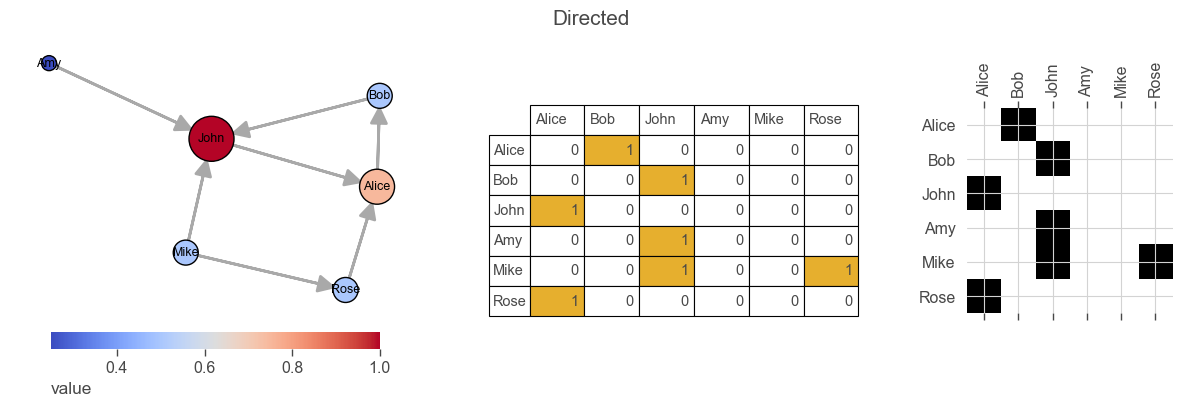

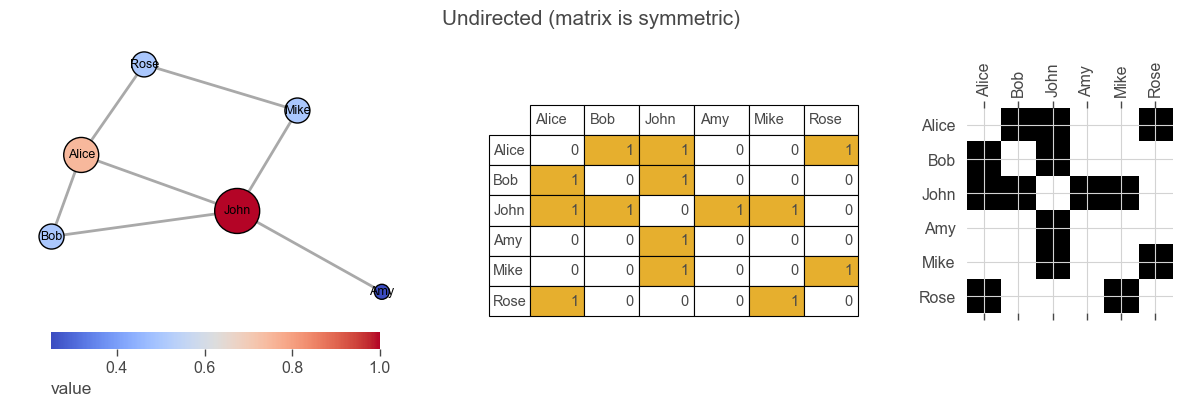

In [5]:
# Create small network
edges = [
    ("Alice", "Bob"),
    ("John",  "Alice"),
    ("Bob",   "John"),
    ("Amy",   "John"),
    ("Mike",  "John"),
    ("Rose",  "Alice"),
    ("Mike",  "Rose"),
]

G_dir = ig.Graph.TupleList(edges, directed=True)
G_undir = ig.Graph.TupleList(edges, directed=False)

plot_network_adj(G_dir)
plt.suptitle("Directed", y=1.02)
plt.show()

plot_network_adj(G_undir)
plt.suptitle("Undirected (matrix is symmetric)", y=1.02)
plt.show()


Notice that the undirected adjacency matrix is **symmetric** (`A == A.T`), while the directed one is generally not.

### 1.2 Convert between formats

The three common representations are:

1. **Edgelist** (DataFrame of source/target) — easy to read, easy to import/export.
2. **Adjacency matrix** (`numpy` array) — perfect for linear algebra.
3. **Graph object** — what `igraph` actually uses to compute on.

A good network library lets you round-trip between all three. Let's do it.


In [6]:
# To edgelist
df = G_dir.get_edge_dataframe()
display(df)

# get the real names
df_vert = G_dir.get_vertex_dataframe()
df['source'] = df['source'].replace(df_vert['name'])
df['target'] = df['target'].replace(df_vert['name'])
display(df)

# To adjacency (as a pandas dataframe to visualize it)
names = G_dir.vs["name"]
A = pd.DataFrame(G_dir.get_adjacency().data, columns=names, index=names)
display(A)

,source,target
edge ID,,
0,0,1
1,2,0
2,1,2
3,3,2
4,4,2
5,5,0
6,4,5


,source,target
edge ID,,
0,Alice,Bob
1,John,Alice
2,Bob,John
3,Amy,John
4,Mike,John
5,Rose,Alice
6,Mike,Rose


,Alice,Bob,John,Amy,Mike,Rose
Alice,0,1,0,0,0,0
Bob,0,0,1,0,0,0
John,1,0,0,0,0,0
Amy,0,0,1,0,0,0
Mike,0,0,1,0,0,1
Rose,1,0,0,0,0,0


### 1.3 Add node metadata

We attach a `children` attribute to each person. This will become the vector we multiply the adjacency matrix by in the next section.


In [7]:
# Attach one node attribute in graph vertex order.
print("Node order:", G_dir.vs["name"])
children_map = {"Alice": 2, "Bob": 0, "John": 2, "Amy": 0, "Mike": 1, "Rose": 5}
G_dir.vs["children"] = [children_map[n] for n in G_dir.vs["name"]]
G_undir.vs["children"] = [children_map[n] for n in G_undir.vs["name"]]

pd.DataFrame({"person": G_dir.vs["name"], "children": G_dir.vs["children"]})


Node order: ['Alice', 'Bob', 'John', 'Amy', 'Mike', 'Rose']


,person,children
0,Alice,2
1,Bob,0
2,John,2
3,Amy,0
4,Mike,1
5,Rose,5


In [8]:
# Print node and edge attributes
print(G_dir.vs.attribute_names())
print(G_dir.es.attribute_names())

['name', 'children']
[]


---

## Section 2: Matrix multiplication = combining neighbour attributes

> **The big idea.** Multiplying by the adjacency matrix `A` is the network's way of **asking a question about neighbours**.
>
> - `A @ x` asks: *"for each node, what is the sum of my neighbours' values of `x`?"*
> - `A @ A` (= `A^2`) asks: *"for each pair of nodes, how many length-2 paths connect them?"*
> - `A @ A @ A` (= `A^3`) asks the same about length-3 paths, and its diagonal counts triangles.
>
> Every linear-algebra operation we do in this practical is a small variation on those two questions.


### 2.1 Average number of children of your friends

For the **undirected** version of the network we want, for each node:

`average_children_of_neighbours = (sum of neighbours' children) / (number of neighbours)`

which in matrix form is:

`avg = (A @ children) / degree`


<Figure size 500x300 with 0 Axes>

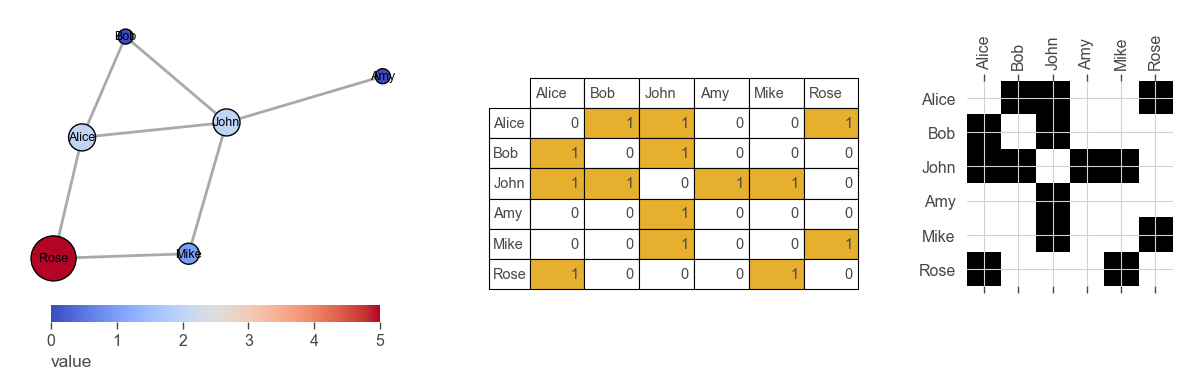

In [9]:
# Create adjacency array
A = np.array(G_undir.get_adjacency().data)
# And the number of children
x = np.array(G_undir.vs["children"], dtype=float)

# Plot network
plt.suptitle("Node colour: number of own children", y=1.02)
plot_network_adj(G_undir, values=x)
plt.show()


In [10]:
# Calculate sum
sum_children = A @ x
# Divide by degree
degree = A.sum(axis=1)
avg_children = sum_children / degree

# Put into a dataframe to explore and visualize
result = pd.DataFrame({
    "person": G_undir.vs["name"],
    "own_children": x.astype(int),
    "neighbours_total": sum_children.astype(int),
    "degree": degree.astype(int),
    "avg_neighbour": np.round(avg_children, 2),
})
display(result)


,person,own_children,neighbours_total,degree,avg_neighbour
0,Alice,2,7,3,2.33
1,Bob,0,4,2,2.00
2,John,2,3,4,0.75
3,Amy,0,2,1,2.00
4,Mike,1,7,2,3.50
5,Rose,5,3,2,1.50


### 2.2 What does `A.T @ x` mean for a directed network?

For the directed `G_dir`, `A[i, j] = 1` means **i points to j**. So `(A @ x)[i]` sums values of nodes that `i` points to (its *out-neighbours*). What does `(A.T @ x)[i]` represent?


,person,A @ x (out-neighbours),A.T @ x (in-neighbours)
0,Alice,0,7
1,Bob,2,2
2,John,2,1
3,Amy,2,0
4,Mike,7,0
5,Rose,2,1


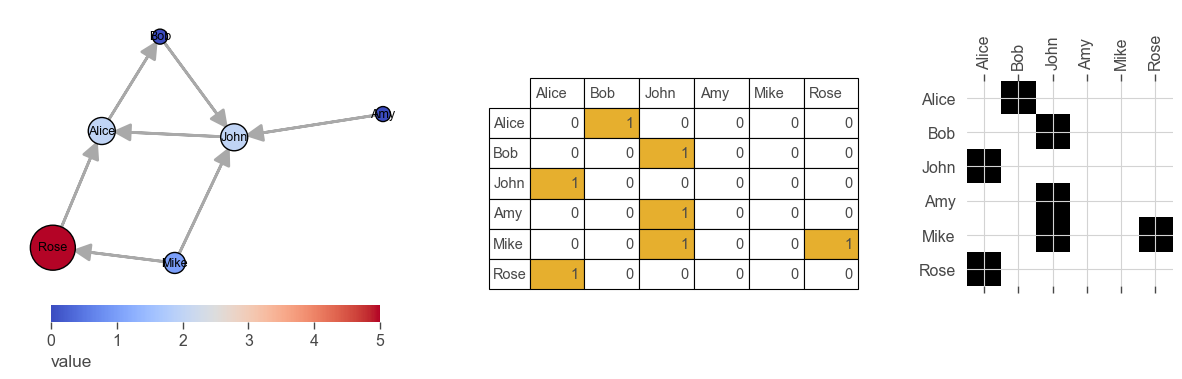

In [11]:
# Student scaffold: transpose the matrix to reverse the direction of the question.
A = np.array(G_dir.get_adjacency().data)
x = np.array(G_dir.vs["children"], dtype=float)
plot_network_adj(G_dir, values=x)

out_neighbour_sum = A @ x
in_neighbour_sum = A.T @ x

pd.DataFrame({
    "person": G_dir.vs["name"],
    "A @ x  (out-neighbours)": out_neighbour_sum.astype(int),
    "A.T @ x (in-neighbours)": in_neighbour_sum.astype(int),
})
# A.T @ x is the network asking: "for each node, what is the sum of values
# coming from my IN-neighbours (the nodes that point at me)?"

---

## Section 3: Matrix multiplication and paths

`A^n` counts **walks** of length `n`: `(A^n)[i, j]` is the number of length-`n` walks from `i` to `j`. This single fact powers:

- counting nodes reachable in at most `k` steps,
- counting triangles,
- the local clustering coefficient.


### 3.1 Walks of length 1, 2 and 3

We compute `A`, `A^2`, `A^3` on the directed network and visualise each as its own graph (an edge from `i` to `j` means "reachable in exactly `n` steps").

`(A + A^2 + A^3) > 0` is the "can I reach node `j` from `i` in 1, 2 or 3 steps?" matrix.


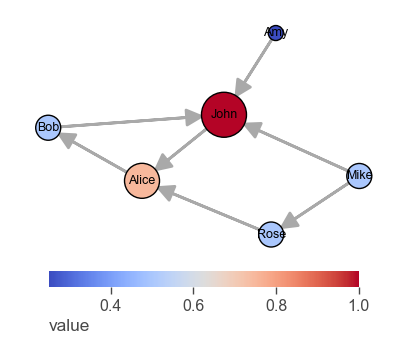

In [12]:
plot_network(G_dir)

In [13]:
# Student scaffold: powers of A count walks of fixed length.
A = np.array(G_dir.get_adjacency().data)
names = tuple(G_dir.vs["name"])

# Student scaffold: combine paths of length 1, 2 and 3, then count reachable nodes.
A = np.array(G_dir.get_adjacency().data)
M = (A + A @ A + A @ A @ A) > 0 # count reachable nodes once
np.fill_diagonal(M, False) # substract yourself
reachable_le_3 = M.sum(axis=1) # sum all nodes reachable

pd.DataFrame({"person": G_dir.vs["name"], "reachable within 3 steps": reachable_le_3})


,person,reachable within 3 steps
0,Alice,2
1,Bob,2
2,John,2
3,Amy,3
4,Mike,4
5,Rose,3


### 3.2 Triangles

The diagonal of `A^3` counts closed walks of length 3 — i.e. triangles, with multiplicity. For an **undirected** simple graph each triangle is counted **6 times** in `trace(A^3)` (3 vertices × 2 directions), so the total number of triangles is `trace(A^3) / 6`.

Compare with `g.cliques(min=3, max=3)`.


In [14]:
# Student scaffold: for undirected graphs, trace(A^3) / 6 counts triangles.
A = np.array(G_undir.get_adjacency().data)
n_tri_matrix = int(np.trace(A @ A @ A) / 6)
n_tri_igraph = len(G_undir.cliques(min=3, max=3))
print(f"Triangles via matrix : {n_tri_matrix}")
print(f"Triangles via igraph : {n_tri_igraph}")


Triangles via matrix : 1
Triangles via igraph : 1


### 3.3 Local clustering coefficient

The local clustering coefficient of node `i` is

```
C_i = (triangles through i) / (number of pairs of neighbours of i)
    = (A^3)[i, i] / 2     /     ( k_i * (k_i - 1) / 2 )
```

Compare to `g.transitivity_local_undirected()`.


In [15]:
# Student scaffold: local clustering compares actual triangles to possible triangles.
A = np.array(G_undir.get_adjacency().data)
tri = (A @ A @ A).diagonal() / 2
degree = A.sum(axis=1)
potential = degree * (degree - 1) / 2
C_manual = tri / potential
C_igraph = G_undir.transitivity_local_undirected(mode="zero")

pd.DataFrame({
    "node": G_undir.vs["name"],
    "triangles": tri,
    "potential": potential,
    "C (manual)": np.round(C_manual, 3),
    "C (igraph)": np.round(C_igraph, 3),
})


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_8777/3732854094.py:6: RuntimeWarning: invalid value encountered in divide
  C_manual = tri / potential


,node,triangles,potential,C (manual),C (igraph)
0,Alice,1.0,3.0,0.333,0.333
1,Bob,1.0,1.0,1.000,1.000
2,John,1.0,6.0,0.167,0.167
3,Amy,0.0,0.0,NaN,0.000
4,Mike,0.0,1.0,0.000,0.000
5,Rose,0.0,1.0,0.000,0.000


---

## Section 4: Node centrality

Centrality measures try to capture, in a single number, **how important** a node is. They disagree because they answer different questions:

| Measure          | Question it answers                                                    |
|------------------|------------------------------------------------------------------------|
| **Degree**       | How many direct connections do I have?                                 |
| **Closeness**    | How short is my average distance to everyone else?                     |
| **Betweenness**  | How often do I sit on a shortest path between two other nodes?         |
| **Eigenvector**  | How well-connected are my neighbours (recursively)?                    |
| **PageRank**     | Like eigenvector, but for directed networks and with a damping factor. |
| **Harmonic**     | Closeness that gracefully handles disconnected components.             |


### 4.1 Florentine families network

We load the classic Florentine marriage network. NetworkX ships it as a convenience constructor; we convert it into igraph and copy the names across.


In [16]:
# Student scaffold: load the Florentine families network.
G_flo_nx = nx.florentine_families_graph()
G_flo = ig.Graph.from_networkx(G_flo_nx)
G_flo.vs["name"] = G_flo.vs["_nx_name"]
print(f"Florentine: n = {G_flo.vcount()}, m = {G_flo.ecount()}")
print("Families:", G_flo.vs["name"])


Florentine: n = 15, m = 20
Families: ['Acciaiuoli', 'Medici', 'Castellani', 'Peruzzi', 'Strozzi', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati', 'Pazzi', 'Bischeri', 'Guadagni', 'Ginori', 'Lamberteschi']


### 4.2 Compute the five centralities

We collect them in a DataFrame for inspection.


In [17]:
# Student scaffold: compute several centralities and compare rankings.
cent = pd.DataFrame({
    "family": G_flo.vs["name"],
    "degree": G_flo.degree(),
    "closeness": G_flo.closeness(),
    "betweenness": G_flo.betweenness(),
    "eigenvector": G_flo.eigenvector_centrality(),
    "pagerank": G_flo.pagerank(),
    "harmonic": G_flo.harmonic_centrality(),
}).set_index("family")

sort_by = "betweenness"  # try: "degree", "closeness", "eigenvector", "pagerank"
cent.sort_values(sort_by, ascending=False).round(3)


,degree,closeness,betweenness,eigenvector,pagerank,harmonic
family,,,,,,
Medici,6,0.560,47.500,1.000,0.146,0.679
Guadagni,4,0.467,23.167,0.672,0.098,0.577
Albizzi,3,0.483,19.333,0.567,0.079,0.560
Salviati,2,0.389,13.000,0.339,0.061,0.470
Ridolfi,3,0.500,10.333,0.794,0.070,0.571
Bischeri,3,0.400,9.500,0.657,0.069,0.514
Strozzi,4,0.438,9.333,0.827,0.088,0.560
Barbadori,2,0.438,8.500,0.492,0.050,0.506
Tornabuoni,3,0.483,8.333,0.757,0.071,0.560


### 4.3 Visualise each centrality on the network

The node size and colour both encode the centrality value, so you can scan the picture and spot the "winners".


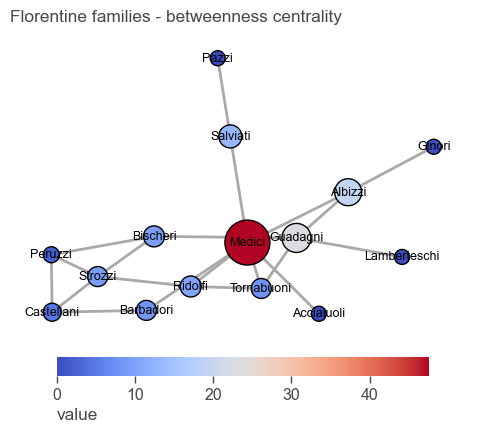

In [18]:
# Small change to try: set `centrality_to_plot = "degree"`.
centrality_to_plot = "betweenness"
vals = cent[centrality_to_plot].values
fig, ax = plt.subplots(figsize=(6, 5))
plot_network(G_flo, ax=ax, values=vals)
ax.set_title(f"Florentine families - {centrality_to_plot} centrality")
plt.show()


---

## Section 5: Centrality on real networks


### 5.1 Twitter network (`ic2s2_netsci_3.tsv`)

Load the directed Twitter network and report the top-10 nodes by closeness, betweenness, PageRank and hub-score (HITS).


In [19]:
df = pd.read_csv(f"{path_data}/ic2s2_netsci_3.tsv", sep="\t")
G_tw = ig.Graph.TupleList(df[["source", "target"]].itertuples(index=False), directed=True)
G_tw.simplify(multiple=False, loops=True)
print(f"Twitter network: n = {G_tw.vcount()}, m = {G_tw.ecount()}")

names_tw = G_tw.vs["name"]

def top_n(values, names, label, n=15):
    s = pd.Series(values, index=names, name=label)
    return s.sort_values(ascending=False).head(n)

cc = top_n(G_tw.closeness(mode="all"),          names_tw,         "closeness")
bc = top_n(G_tw.betweenness(directed=True),     names_tw,         "betweenness")
pr = top_n(G_tw.pagerank(directed=True),        names_tw,         "pagerank")
hb = top_n(G_tw.hub_score(),                    names_tw,         "hub_score")
ab = top_n(G_tw.authority_score(),              names_tw,         "authority_score")

pd.concat([cc, bc, pr, hb, ab], axis=1).sort_values(by="authority_score", ascending=False)


Twitter network: n = 1554, m = 52840


,closeness,betweenness,pagerank,hub_score,authority_score
LHDnets,NaN,NaN,0.010831,0.359590,1.000000
cosnet_bifi,0.530396,NaN,0.007666,0.417143,0.657002
netscisociety,NaN,NaN,0.010148,NaN,0.635875
uvmcomplexity,NaN,NaN,0.006713,NaN,0.601672
lordgrilo,0.531303,71012.790828,NaN,0.504298,0.593498
_jgyou,NaN,NaN,0.007296,0.391807,0.576206
fede7j,0.531485,62445.170638,NaN,0.526993,0.574063
juniperlov,NaN,NaN,NaN,0.387441,0.552635
all_are,NaN,NaN,NaN,NaN,0.522322
manlius84,0.554247,142397.283156,0.007167,0.849837,0.508030


### 5.2 Protein-protein interaction network

Same exercise on the yeast PPI network. The top nodes by closeness/betweenness/eigenvector tend to be hub proteins central to cellular machinery.

> `YLR291C` is a known hub: it is involved in regulation of translational initiation.


In [20]:
G_ppi = ig.Graph.Read_GraphML(f"{path_data}/ppi_network_prediction.graphml")
G_ppi.to_undirected(mode="collapse")
# Use the "label" attribute as the node name if available
if "label" in G_ppi.vs.attributes():
    G_ppi.vs["name"] = G_ppi.vs["label"]
print(f"PPI: n = {G_ppi.vcount()}, m = {G_ppi.ecount()}")

names_ppi = G_ppi.vs["name"]


cc_p = top_n(G_ppi.degree(),                    names_ppi,  "degree")
bc_p = top_n(G_ppi.betweenness(),               names_ppi,  "betweenness")
ec_p = top_n(G_ppi.eigenvector_centrality(),    names_ppi,  "eigenvector")

pd.concat([cc_p, bc_p, ec_p], axis=1)


PPI: n = 964, m = 1202


,degree,betweenness,eigenvector
YLR291C,68.0,128811.280097,1.000000
YLR423C,48.0,49232.103368,0.307401
YIR038C,37.0,20739.530674,NaN
YDR510W,32.0,56682.208598,NaN
YBR261C,31.0,33427.152097,0.443005
YDR479C,29.0,20292.849744,NaN
YML051W,23.0,21758.306474,NaN
YPL094C,22.0,NaN,NaN
YPL070W,22.0,NaN,0.418789
YDR100W,22.0,22095.624647,NaN


### 5.3 Discussion

Look at the rankings above and discuss with your neighbour, in the Twitter network:

- **Who would you choose to spread news quickly** (assuming the news is *always* passed on)?
- **Who connects different communities** (acts as a bridge between groups)?
- **Who would be best for spreading unreliable news** (assuming the news is sometimes *not* passed on)?

There are no single right answers. The answers depend on which centrality you trust for each question, and that is exactly the point of having more than one.


---

## Section 6: Eigenvector centrality and PageRank, by hand
[advanced, only if you love math]

### Scaffold A — the idea

Eigenvector centrality is built on a simple, almost circular, idea:

> **A node is important if its neighbours are important.**

That sounds like we're chasing our own tail, but watch what happens when we turn it into an equation.


### Scaffold B — turning the idea into a formula

Call each node's importance `x_i`. The statement *"my importance is the sum of my neighbours' importances"* reads:

$$ x_i = \sum_j{A_{i, j}  x_j} $$

In vector form, that's `x = A x`. Almost an eigenvector equation, but `A x` will keep growing (or shrinking) every time we apply `A`, so to keep magnitudes stable we normalise:

`x = (A x) / λ`

where λ is just a normalising constant. Rearranging:

`A x = λ x`

That **is** the eigenvalue equation. The eigenvector of `A` with the largest eigenvalue λ is exactly what we call **eigenvector centrality**.


### Scaffold C — the power method

You don't need to call an eigensolver to find `x`. Start with `x = (1, 1, …, 1)` and repeat:

```
x  <-  A x
x  <-  x / ||x||
```

After enough iterations `x` converges to the dominant eigenvector. That repeated multiply-and-normalise is the **power method**.


### 6.1 Eigenvector centrality with the power method

We run 5 iterations on `G_undir` and print the result side-by-side with `g.eigenvector_centrality()`.


In [21]:
# Student scaffold: watch the power method converge for five iterations.
A_u = np.array(G_undir.get_adjacency().data, dtype=float)
N   = G_undir.vcount()

n = 20

x = np.ones(N)
rows = []
for i in range(n):
    x = A_u @ x
    x = x / np.linalg.norm(x)
    rows.append(np.round(x, 3))

iter_df = pd.DataFrame(rows, columns=G_undir.vs["name"])
iter_df.index = [f"iter {i+1}" for i in range(n)]

reference = np.array(G_undir.eigenvector_centrality())
reference = reference / np.linalg.norm(reference)
iter_df.loc["igraph"] = np.round(reference, 3)
iter_df


,Alice,Bob,John,Amy,Mike,Rose
iter 1,0.487,0.324,0.649,0.162,0.324,0.324
iter 2,0.502,0.439,0.502,0.251,0.376,0.314
iter 3,0.484,0.387,0.605,0.193,0.314,0.339
iter 4,0.512,0.419,0.531,0.233,0.363,0.307
iter 5,0.484,0.401,0.588,0.204,0.323,0.337
iter 6,0.510,0.412,0.543,0.226,0.356,0.310
iter 7,0.487,0.406,0.579,0.209,0.329,0.333
iter 8,0.507,0.410,0.550,0.223,0.351,0.314
iter 9,0.490,0.407,0.574,0.212,0.333,0.330
iter 10,0.504,0.410,0.555,0.221,0.348,0.317


### 6.2 PageRank with the power method

For PageRank we

1. row-normalise the adjacency matrix: `A_hat = D^(-1) A`, 
2. mix in a teleportation term with damping factor `d = 0.85`: `M = d * A_hat + (1 - d) / N`,
3. iterate `x <- x @ M` until convergence (note: row-stochastic, so we left-multiply).


In [22]:
# Student scaffold: PageRank is a random walk plus teleportation.
# Small change to try: set `damping = 0.50` and compare the result.
A = np.array(G_dir.get_adjacency().data, dtype=float)
N = G_dir.vcount()
damping = 0.85

deg_out = A.sum(axis=1)
D = np.diag(1.0 / np.where(deg_out > 0, deg_out, 1.0))
A_h = D @ A

x = np.ones(N) / N
for _ in range(100):
    x = x @ (damping * A_h + (1 - damping) / N)

ref = np.array(G_dir.pagerank(damping=damping))
pd.DataFrame({"manual": np.round(x, 4), "igraph": np.round(ref, 4)}, index=G_dir.vs["name"])


,manual,igraph
Alice,0.3154,0.3154
Bob,0.2931,0.2931
John,0.3060,0.3060
Amy,0.0250,0.0250
Mike,0.0250,0.0250
Rose,0.0356,0.0356


### 6.3 Random walker on an undirected graph ≈ degree centrality

If you let a random walker bounce around an undirected graph forever, the fraction of time it spends at node `i` is proportional to its **degree**. That's why on undirected graphs PageRank (without damping) reduces to degree centrality.


In [23]:
# Student scaffold: on an undirected graph, long-run random-walk visits track degree.
A = np.array(G_undir.get_adjacency().data, dtype=float)
N = G_undir.vcount()
D = np.diag(1.0 / np.maximum(A.sum(axis=1), 1))
A_h = D @ A

x = np.ones(N) / N
for _ in range(100):
    x = x @ A_h

x = x / np.linalg.norm(x)
deg = np.array(G_undir.degree(), dtype=float)
deg = deg / np.linalg.norm(deg)
pd.DataFrame({"random-walker": np.round(x, 4), "degree (normalised)": np.round(deg, 4)}, index=G_undir.vs["name"])


,random-walker,degree (normalised)
Alice,0.4867,0.4867
Bob,0.3244,0.3244
John,0.6489,0.6489
Amy,0.1622,0.1622
Mike,0.3244,0.3244
Rose,0.3244,0.3244


---

## Section 7: Centrality side-by-side

Different centralities crown different nodes as "most important". To make that concrete, here is the **same** Florentine network drawn four times, with nodes sized by four different centralities. The same Fruchterman-Reingold layout is used in each panel so you can compare positions at a glance.


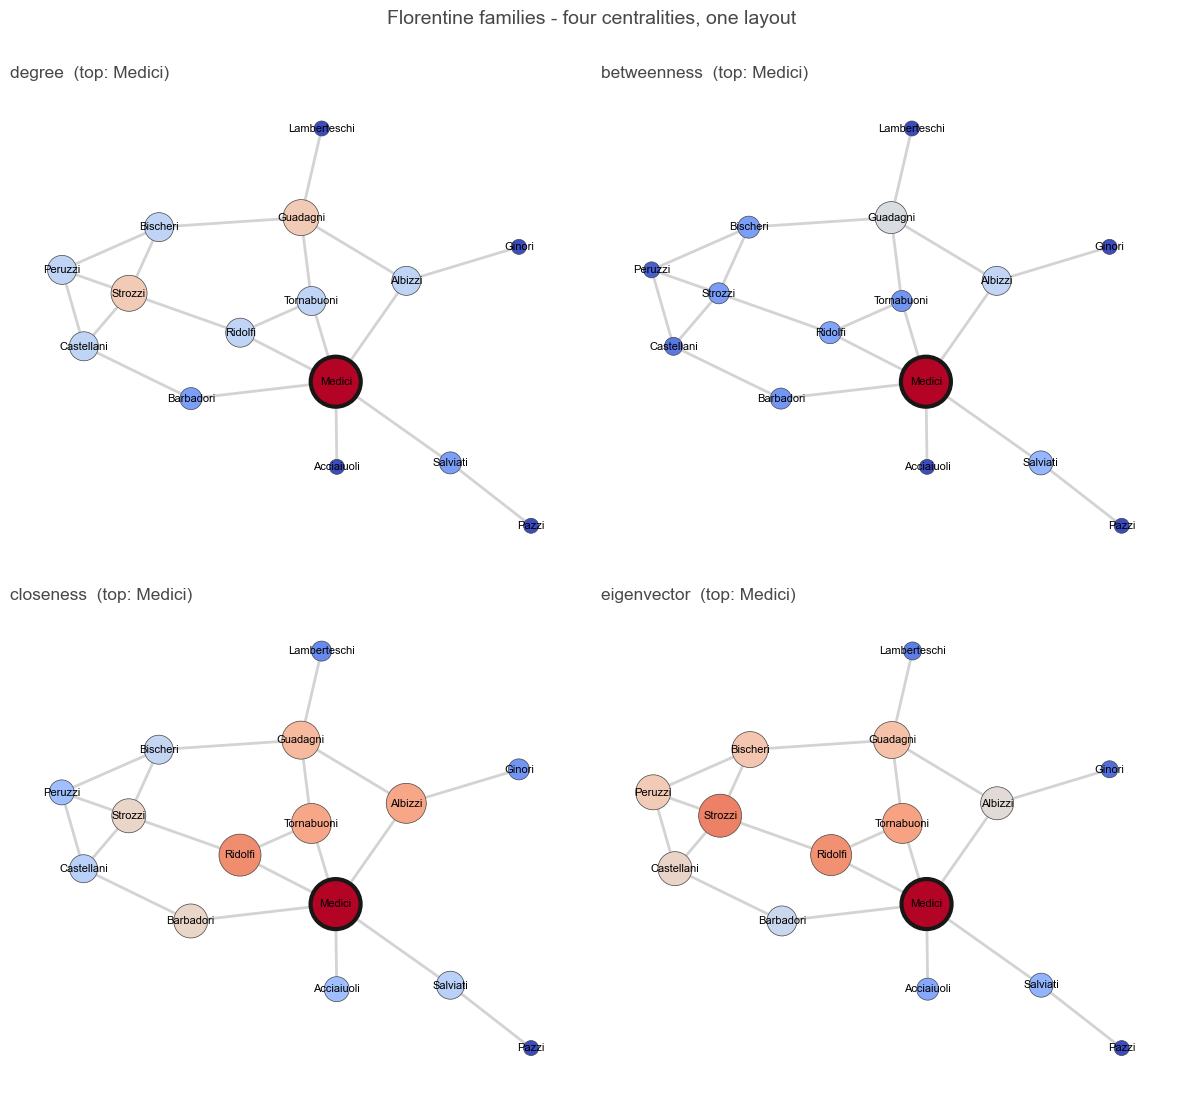

In [24]:
layout = G_flo.layout_fruchterman_reingold()
names_flo = G_flo.vs["name"]

centralities = {
    "degree":       np.array(G_flo.degree(),                dtype=float),
    "betweenness":  np.array(G_flo.betweenness(),           dtype=float),
    "closeness":    np.array(G_flo.closeness(),             dtype=float),
    "eigenvector":  np.array(G_flo.eigenvector_centrality(),dtype=float),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, (cname, vals) in zip(axes.ravel(), centralities.items()):
    span = max(vals.max() - vals.min(), 1e-9)
    sizes = 15 + 35 * (vals - vals.min()) / span

    # Continuous color encoding (coolwarm), consistent with plot_network() above
    norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.coolwarm)
    colors = [mapper.to_rgba(v) for v in vals]

    # Mark the top node with a thicker frame so it stands out at a glance
    top = int(np.argmax(vals))
    frame_widths = [0.5] * G_flo.vcount()
    frame_widths[top] = 3.0
    frame_colors = ["#444444"] * G_flo.vcount()
    frame_colors[top] = "#191716"

    ig.plot(
        G_flo,
        target=ax,
        layout=layout,
        vertex_size=sizes,
        vertex_color=colors,
        vertex_frame_color=frame_colors,
        vertex_frame_width=frame_widths,
        edge_color="lightgray",
        vertex_label=names_flo,
        vertex_label_size=8,
    )
    ax.set_axis_off()
    ax.set_title(f"{cname}  (top: {names_flo[top]})")

plt.suptitle("Florentine families - four centralities, one layout", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

Take-away. The Medici rank highest on most centrality measures, echoing their historical dominance. But the Strozzi move up or down depending on the metric: they have many connections and strong local clustering, yet sit off-center in the network, which lowers their betweenness.

Same network, different measures, different “winners” — which is why we use more than one measure of centrality.